# **Extreme Classification by Optimizing Compositional Entropic Risk (SCENT)**


## Prerequisites

In [1]:
# !gdown --folder 'https://drive.google.com/drive/folders/10cY2Azqz9Gnci-r4fXcGIpH_e5YaKXH_?usp=sharing' -O ./features

In [2]:
# !git clone https://github.com/xywei00/LibAUC.git -b xiyuan/1.5.0_dev

In [3]:
# !pip install ./LibAUC

In [4]:
import os
import logging
import pathlib
import json
import sys
import random
import math

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR

from libauc.losses import EntLossClassification
from libauc.optimizers import SCENT

## Helper Functions

In [5]:
class LinearClassifier(nn.Module):
    def __init__(self, feature_dim: int, num_classes: int):
        super().__init__()
        self.feature_dim = feature_dim
        self.num_classes = num_classes
        self.fc = nn.Linear(feature_dim, num_classes, bias=False)
        nn.init.normal_(self.fc.weight, mean=0.0, std=0.01)

    def forward(
        self,
        x: torch.Tensor,
        labels: torch.Tensor,
        classes: torch.Tensor | str | None = None,
        return_classes: bool = False,
    ):
        w_pos = self.fc.weight[labels]  # (B, D)

        mask = None
        sampled_classes = None
        if isinstance(classes, str):
            assert classes == "all"
            sampled_classes = torch.arange(self.num_classes, device=labels.device)
            w_sampled = self.fc.weight
        elif isinstance(classes, torch.Tensor):
            sampled_classes = classes.to(labels.device)
            w_sampled = self.fc.weight[sampled_classes]
        elif classes is None:
            sampled_classes = torch.unique(labels)
            w_sampled = self.fc.weight[sampled_classes]
            mask = labels.unsqueeze(1) == sampled_classes.unsqueeze(0)
        else:
            raise ValueError(f"Unknown classes type: {type(classes)}")

        logits = x @ w_sampled.T - torch.sum(x * w_pos, dim=1, keepdim=True)

        if mask is not None:
            logits = logits.masked_fill(mask.to(logits.device), float("-inf"))

        if return_classes:
            return logits, sampled_classes
        return logits

In [6]:
class FeaturesDataset(Dataset):
    """Dataset for precomputed features.

    Expects features_path (N, D) and labels_path (N,) where labels are ints 0..C-1.
    """

    def __init__(self, features_path: str, labels_path: str):
        self.features = torch.load(features_path, map_location="cpu")
        self.labels = torch.load(labels_path, map_location="cpu")
        assert self.features.shape[0] == self.labels.shape[0], "features/labels length mismatch"

    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, idx):
        x = self.features[idx]
        y = self.labels[idx]
        return x, y, idx

In [7]:
def setup_logging(out_log_file=None):
    logging.root.handlers = []
    logging.root.setLevel(level=logging.INFO)

    formatter = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(message)s", datefmt="%Y-%m-%d,%H:%M:%S"
    )

    stream_handler = logging.StreamHandler()
    stream_handler.setFormatter(formatter)
    logging.root.addHandler(stream_handler)

    if out_log_file is not None:
        file_handler = logging.FileHandler(out_log_file)
        file_handler.setFormatter(formatter)
        logging.root.addHandler(file_handler)


def build_dataloaders(root_data_dir, batch_size, num_workers=0):
    dataloader_list = []
    for split, shuffle in zip(["train", "val", "test"], [True, False, False]):
        data_dir = os.path.join(root_data_dir, split)
        if not os.path.exists(data_dir):
            if split in ["train", "val"]:
                raise FileNotFoundError(f"Data directory {data_dir} does not exist.")
            dataloader_list.append(None)
            continue

        features = os.path.join(data_dir, "features.pt")
        labels = os.path.join(data_dir, "labels.pt")
        ds = FeaturesDataset(features, labels)
        dataloader = DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=num_workers,
        )
        dataloader_list.append(dataloader)

    train_loader, val_loader, test_loader = dataloader_list
    return train_loader, val_loader, test_loader


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    logging.info(f"Set random seed to {seed}")


def compute_log_priors(train_loader, num_classes):
    counts = torch.zeros(num_classes, dtype=torch.float32)
    for _, labels, _ in train_loader:
        counts += torch.bincount(labels, minlength=num_classes).float()
    priors = counts / counts.sum()
    priors = priors.clamp_min(1e-12)
    return priors.log()


def apply_la_to_sampled_logits(logits, sampled_classes, labels, log_priors, tau):
    if tau <= 0:
        return logits
    neg_shift = log_priors[sampled_classes].unsqueeze(0)
    pos_shift = log_priors[labels].unsqueeze(1)
    return logits + tau * (neg_shift - pos_shift)


def evaluate(model, loader, device, log_priors=None, eval_tau=0.0):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for i, batch in enumerate(loader):
            feats, labels, _ = batch
            feats = feats.to(device)
            labels = labels.to(device, dtype=torch.long)

            logits = model.fc(feats)

            if log_priors is not None and eval_tau > 0:
                logits = logits + eval_tau * log_priors.to(device).unsqueeze(0)

            loss = F.cross_entropy(logits, labels)
            total_loss += loss.item() * feats.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += feats.size(0)

            if i % 100 == 0:
                logging.info(f"  Batch {i} / {len(loader)}: loss={loss.item():.6f}")

    return total_loss / total, correct / total


def train_one_epoch(model, loader, optimizer, criterion, device, log_priors=None, train_tau=0.0):
    model.train()
    total_loss = 0.0
    total = 0

    for i, batch in enumerate(loader):
        feats, labels, indices = batch
        feats = feats.to(device)
        labels = labels.to(device, dtype=torch.long)

        logits, sampled_classes = model(feats, labels, return_classes=True)
        logits = apply_la_to_sampled_logits(logits, sampled_classes, labels, log_priors, train_tau)

        loss_dict = criterion(logits, indices)
        loss = loss_dict["loss"]

        with torch.no_grad():
            model.eval()
            base_logits = model.fc(feats)
            cross_entropy_loss = F.cross_entropy(base_logits, labels)
            loss_dict["cross_entropy_loss"] = cross_entropy_loss
            model.train()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += cross_entropy_loss.item() * feats.size(0)
        total += feats.size(0)

        if i % 100 == 0:
            log_str = f"  Batch {i} / {len(loader)}:"
            for key, value in loss_dict.items():
                log_str += f" {key}={value.item():.6f}"
            logging.info(log_str)

    return total_loss / total


def make_scheduler(optimizer, epochs, warmup_epochs=0):
    def lr_lambda(epoch_idx):
        epoch_num = epoch_idx + 1
        if warmup_epochs > 0 and epoch_num <= warmup_epochs:
            return epoch_num / warmup_epochs

        if epochs == warmup_epochs:
            return 1.0

        progress = (epoch_num - warmup_epochs) / max(1, epochs - warmup_epochs)
        progress = min(max(progress, 0.0), 1.0)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

In [8]:
data_dir = "./features/treeoflife10m_subset"
root_out_dir = "./outputs_exp5_final/"

seed = 2026
device = "cuda"
feature_dim = 512
num_classes = 163002
data_size = 762654
save_frequency = 1

epochs = 20
batch_size = 128

setup_logging()

In [9]:
EXPERIMENTS = [
    # Plain SCENT reference
    dict(
        name="exp5_cfg01_scent_ref",
        algorithm="scent",
        lr=0.002,
        alpha=0.0,
        alpha_multiplier=0.03,
        momentum=0.9,
        weight_decay=0.0,
        train_tau=0.0,
        eval_tau=0.0,
        warmup_epochs=0,
    ),

    # Final selected method: SCENT + warmup
    dict(
        name="exp5_cfg02_scent_warmup_final",
        algorithm="scent",
        lr=0.002,
        alpha=0.0,
        alpha_multiplier=0.03,
        momentum=0.9,
        weight_decay=0.0,
        train_tau=0.0,
        eval_tau=0.0,
        warmup_epochs=2,
    ),

    # Optional final polish: same training as cfg02, but post-hoc LA at evaluation
    dict(
        name="exp5_cfg03_scent_warmup_posthoc_final",
        algorithm="scent",
        lr=0.002,
        alpha=0.0,
        alpha_multiplier=0.03,
        momentum=0.9,
        weight_decay=0.0,
        train_tau=0.0,
        eval_tau=0.25,
        warmup_epochs=2,
    ),
]

## Training

In [10]:
def build_experiment(cfg):
    name = cfg["name"]
    out_dir = pathlib.Path(root_out_dir) / name
    os.makedirs(out_dir / "checkpoints", exist_ok=True)
    out_log_file = out_dir / "out.log"

    setup_logging(out_log_file)
    set_seed(seed)

    train_loader, val_loader, test_loader = build_dataloaders(data_dir, batch_size, num_workers=0)
    model = LinearClassifier(feature_dim, num_classes).to(device)

    optimizer = SCENT(
        model.parameters(),
        lr=cfg["lr"],
        momentum=cfg["momentum"],
        weight_decay=cfg["weight_decay"],
    )

    lr_scheduler = make_scheduler(
        optimizer,
        epochs=epochs,
        warmup_epochs=cfg["warmup_epochs"],
    )

    if cfg["algorithm"] == "scent":
        criterion = EntLossClassification(
            data_size=data_size,
            alpha=cfg["alpha"],
            is_scent=True,
            alpha_multiplier=cfg["alpha_multiplier"],
        )
    elif cfg["algorithm"] == "sox":
        criterion = EntLossClassification(
            data_size=data_size,
            gamma=cfg["gamma"],
            is_scent=False,
        )
    else:
        raise ValueError(cfg["algorithm"])

    log_priors = compute_log_priors(train_loader, num_classes).to(device)

    return {
        "name": name,
        "out_dir": out_dir,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "model": model,
        "optimizer": optimizer,
        "lr_scheduler": lr_scheduler,
        "criterion": criterion,
        "log_priors": log_priors,
    }


def run_experiment(cfg):
    exp = build_experiment(cfg)

    name = exp["name"]
    out_dir = exp["out_dir"]
    train_loader = exp["train_loader"]
    val_loader = exp["val_loader"]
    test_loader = exp["test_loader"]
    model = exp["model"]
    optimizer = exp["optimizer"]
    lr_scheduler = exp["lr_scheduler"]
    criterion = exp["criterion"]
    log_priors = exp["log_priors"]

    best_val_acc = 0.0
    best_test_acc = 0.0
    best_test_loss = float("inf")
    all_rows = []

    eval_path = out_dir / f"eval_{name}.jsonl"
    if eval_path.exists():
        eval_path.unlink()
    for epoch in range(1, epochs + 1):
        logging.info(
            f"{name} | Epoch {epoch}/{epochs}, learning_rate={lr_scheduler.get_last_lr()[0]:.6f}"
        )

        if hasattr(criterion, "adjust_gamma"):
            criterion.adjust_gamma(epoch, epochs)

        train_ce = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
            log_priors=log_priors,
            train_tau=cfg["train_tau"],
        )

        lr_scheduler.step()

        logging.info("Evaluating on validation set")
        val_loss, val_acc = evaluate(
            model,
            val_loader,
            device,
            log_priors=log_priors,
            eval_tau=cfg["eval_tau"],
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            if test_loader is not None:
                logging.info("Evaluating on test set")
                best_test_loss, best_test_acc = evaluate(
                    model,
                    test_loader,
                    device,
                    log_priors=log_priors,
                    eval_tau=cfg["eval_tau"],
                )

        row = {
            "epoch": epoch,
            "cross_entropy_loss": train_ce,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "best_val_acc": best_val_acc,
            "best_test_acc": best_test_acc,
            "best_test_loss": best_test_loss,
        }
        all_rows.append(row)

        logging.info(
            f"{name} | epoch={epoch} train_ce={train_ce:.6f} "
            f"val_loss={val_loss:.6f} val_acc={val_acc:.6f} "
            f"best_val_acc={best_val_acc:.6f} "
            f"best_test_acc={best_test_acc:.6f}"
        )

        with open(eval_path, "a") as f:
            f.write(json.dumps(row) + "\n")

        if epoch % save_frequency == 0 or epoch == epochs:
            save_dict = {
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "epoch": epoch,
                "config": cfg,
            }
            if hasattr(criterion, "nu"):
                save_dict["criterion_nu"] = criterion.nu.cpu()
            torch.save(save_dict, out_dir / "checkpoints" / f"epoch_{epoch}.pt")

    return all_rows

In [11]:
run_experiment(EXPERIMENTS[0])  # exp5_cfg01_scent_ref
run_experiment(EXPERIMENTS[1])  # exp5_cfg02_scent_warmup_final
run_experiment(EXPERIMENTS[2])  # exp5_cfg03_scent_warmup_posthoc_final

2026-04-21,18:47:38 | INFO | Set random seed to 2026
2026-04-21,18:47:44 | INFO | exp5_cfg01_scent_ref | Epoch 1/20, learning_rate=0.001988
2026-04-21,18:47:44 | INFO |   Batch 0 / 5959: loss=1.000000 cross_entropy_loss=12.003008
2026-04-21,18:47:45 | INFO |   Batch 100 / 5959: loss=1.000000 cross_entropy_loss=11.985226
2026-04-21,18:47:46 | INFO |   Batch 200 / 5959: loss=1.000000 cross_entropy_loss=11.985254
2026-04-21,18:47:47 | INFO |   Batch 300 / 5959: loss=1.000000 cross_entropy_loss=11.963253
2026-04-21,18:47:48 | INFO |   Batch 400 / 5959: loss=1.000000 cross_entropy_loss=11.963149
2026-04-21,18:47:49 | INFO |   Batch 500 / 5959: loss=1.000000 cross_entropy_loss=11.953777
2026-04-21,18:47:50 | INFO |   Batch 600 / 5959: loss=1.000000 cross_entropy_loss=11.912365
2026-04-21,18:47:50 | INFO |   Batch 700 / 5959: loss=1.000000 cross_entropy_loss=11.899681
2026-04-21,18:47:51 | INFO |   Batch 800 / 5959: loss=1.000000 cross_entropy_loss=11.908283
2026-04-21,18:47:52 | INFO |   Bat

[{'epoch': 1,
  'cross_entropy_loss': 11.748723199008532,
  'val_loss': 10.080850767429792,
  'val_acc': 0.13384942988115095,
  'best_val_acc': 0.13384942988115095,
  'best_test_acc': 0.0,
  'best_test_loss': inf},
 {'epoch': 2,
  'cross_entropy_loss': 11.35574456599131,
  'val_loss': 9.839687282997502,
  'val_acc': 0.13384942988115095,
  'best_val_acc': 0.13384942988115095,
  'best_test_acc': 0.0,
  'best_test_loss': inf},
 {'epoch': 3,
  'cross_entropy_loss': 11.115194981125816,
  'val_loss': 9.638059366073358,
  'val_acc': 0.13384942988115095,
  'best_val_acc': 0.13384942988115095,
  'best_test_acc': 0.0,
  'best_test_loss': inf},
 {'epoch': 4,
  'cross_entropy_loss': 10.895836639042662,
  'val_loss': 9.456634048463675,
  'val_acc': 0.13404873545856016,
  'best_val_acc': 0.13404873545856016,
  'best_test_acc': 0.0,
  'best_test_loss': inf},
 {'epoch': 5,
  'cross_entropy_loss': 10.689211376745103,
  'val_loss': 9.293549133384253,
  'val_acc': 0.13423755126873735,
  'best_val_acc': 0

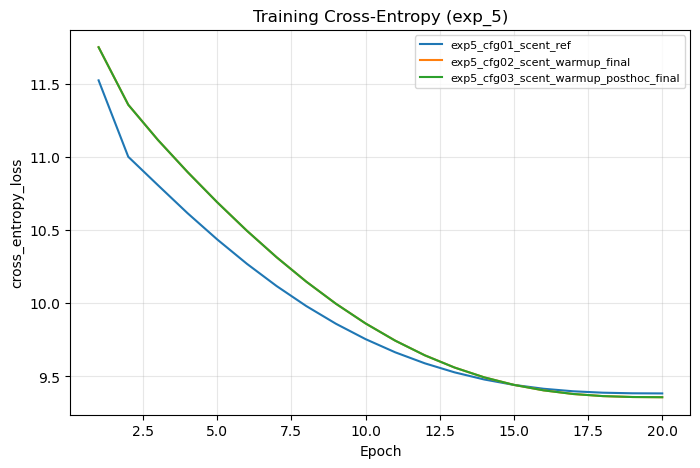

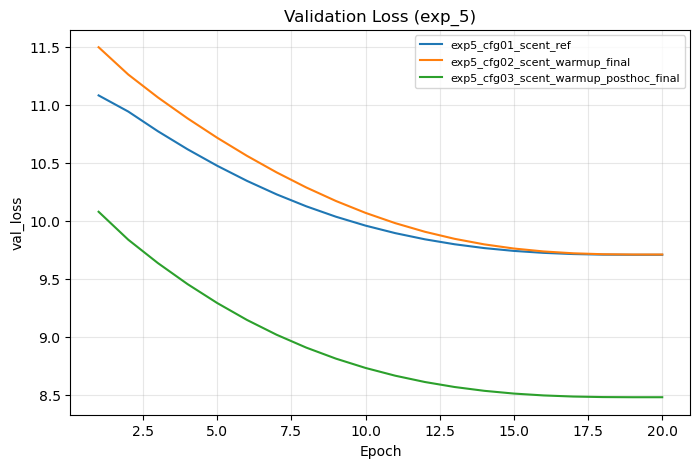

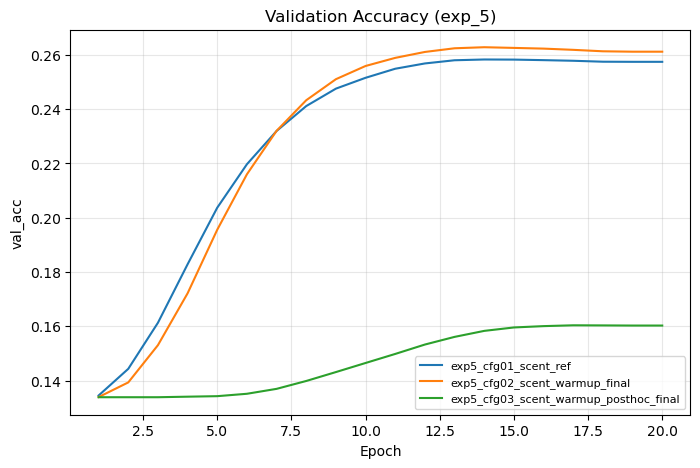

In [13]:
import matplotlib.pyplot as plt

def load_jsonl(path):
    rows = []
    with open(path, "r") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows


def load_run(name):
    path = pathlib.Path(root_out_dir) / name / f"eval_{name}.jsonl"
    return load_jsonl(path)


def plot_metric(names, metric, title):
    plt.figure(figsize=(8, 5))
    for name in names:
        rows = load_run(name)
        xs = [r["epoch"] for r in rows]
        ys = [r[metric] for r in rows]
        plt.plot(xs, ys, label=name)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.show()

names = [cfg["name"] for cfg in EXPERIMENTS]

plot_metric(names, "cross_entropy_loss", "Training Cross-Entropy (exp_5)")
plot_metric(names, "val_loss", "Validation Loss (exp_5)")
plot_metric(names, "val_acc", "Validation Accuracy (exp_5)")